In [ ]:
import os, warnings
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import learning_curve, KFold
from sklearn.metrics import  accuracy_score, r2_score, make_scorer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [3]:
df = pd.read_csv("coffee_value_benchmark.csv")
split = pd.read_csv("coffee_benchmark_splits.csv")
metadata = pd.read_csv("coffee_record_metadata.csv")
feature = pd.read_csv("feature_dictionary.csv")
df = df.merge(metadata[["record_id", "record_type"]], on="record_id")
df = df[df.record_type == "Original"].drop(columns="record_type").merge(split, on="lot_id")
df["certification"] = df["certification"].fillna("None")
train = df[df.temporal_split == "Train"].reset_index(drop=True)
test = df[df.temporal_split != "Train"].reset_index(drop=True)

In [4]:
feature.head(12)

,column,stage,data_type,description,prediction_timing,usable_as_feature_for_quality,usable_as_feature_for_sensory,usable_as_feature_for_price
0,record_id,Metadata,string,Unique primary key for each observation row.,NaN,False,False,False
1,lot_id,Metadata,string,Entity identifier representing the physical ag...,NaN,False,False,False
2,harvest_season,Environment,category,Agricultural harvest season window.,Pre-harvest,True,True,True
3,harvest_calendar_year,Environment,integer,Calendar year corresponding to the harvest month.,Pre-harvest,True,True,True
4,harvest_month,Environment,integer,Calendar month of harvest pickings.,Pre-harvest,True,True,True
5,country_of_origin,Farm,category,Producing country.,Pre-harvest,True,True,True
6,farm_type,Farm,category,Operational and organizational structure of th...,Pre-harvest,True,True,True
7,farm_size_hectares,Farm,float,Total cultivated coffee area in hectares.,Pre-harvest,True,True,True
8,tree_age_years,Farm,float,Mean age of producing coffee trees.,Pre-harvest,True,True,True
9,altitude_mean_meters,Environment,float,Mean plantation altitude above sea level.,Pre-harvest,True,True,True


In [5]:
pd.set_option('display.max_columns', None)
print(feature.columns.tolist())

['column', 'stage', 'data_type', 'description', 'prediction_timing', 'usable_as_feature_for_quality', 'usable_as_feature_for_sensory', 'usable_as_feature_for_price']


In [6]:


feature_str = feature.select_dtypes(include=['object', 'str']).columns

for col in feature_str:
    print(feature[col].unique())

<StringArray>
[             'record_id',                 'lot_id',         'harvest_season',
  'harvest_calendar_year',          'harvest_month',      'country_of_origin',
              'farm_type',     'farm_size_hectares',         'tree_age_years',
   'altitude_mean_meters',                'species',             'avg_temp_c',
 'avg_annual_rainfall_mm',           'humidity_pct',      'processing_method',
          'drying_method',   'drying_duration_days',         'storage_months',
     'storage_conditions',       'bean_size_screen',           'moisture_pct',
      'bean_density_g_ml',        'defect_rate_pct',     'traceability_level',
          'certification', 'intended_buyer_segment',            'lot_size_kg',
            'roast_level',          'acidity_score',        'sweetness_score',
             'body_score',            'aroma_score',           'flavor_score',
   'coffee_quality_score',          'quality_grade',       'price_usd_per_kg']
Length: 36, dtype: str
<StringArray>
[

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(feature[['column', 'stage', 'data_type', 'description', 'prediction_timing', 'usable_as_feature_for_quality', 
                'usable_as_feature_for_sensory', 'usable_as_feature_for_price']].to_string())

                    column        stage data_type                                                                                                                                                                 description prediction_timing  usable_as_feature_for_quality  usable_as_feature_for_sensory  usable_as_feature_for_price
0                record_id     Metadata    string                                                                                                                                Unique primary key for each observation row.               NaN                          False                          False                        False
1                   lot_id     Metadata    string                                                                                Entity identifier representing the physical agricultural lot. Use for GroupKFold validation.               NaN                          False                          False                        False
2      

In [8]:
quality_features =  feature[feature['usable_as_feature_for_quality'] == True]['column'].to_list()

X_quality = df[quality_features]

y_quality_reg = df['coffee_quality_score']
y_quality_cls = df['quality_grade']

In [9]:
cols_drop = ['record_id', 'lot_id', 'roast_level', 'acidity_score', 
                 'sweetness_score', 'body_score', 'aroma_score', 'flavor_score',
                 'coffee_quality_score', 'quality_grade', 'price_usd_per_kg']

X = df.drop(df[cols_drop], axis=1)

                           n   pct
record_id                  0  0.00
lot_id                     0  0.00
harvest_season             0  0.00
harvest_calendar_year      0  0.00
harvest_month              0  0.00
country_of_origin          0  0.00
farm_type                  0  0.00
farm_size_hectares         0  0.00
tree_age_years             0  0.00
altitude_mean_meters       0  0.00
species                    0  0.00
avg_temp_c                 0  0.00
avg_annual_rainfall_mm  1488  5.02
humidity_pct            1889  6.37
processing_method          0  0.00
drying_method              0  0.00
drying_duration_days       0  0.00
storage_months             0  0.00
storage_conditions         0  0.00
bean_size_screen           0  0.00
moisture_pct            1587  5.35
bean_density_g_ml       1607  5.42
defect_rate_pct            0  0.00
traceability_level         0  0.00
certification              0  0.00
intended_buyer_segment     0  0.00
lot_size_kg                0  0.00
roast_level         

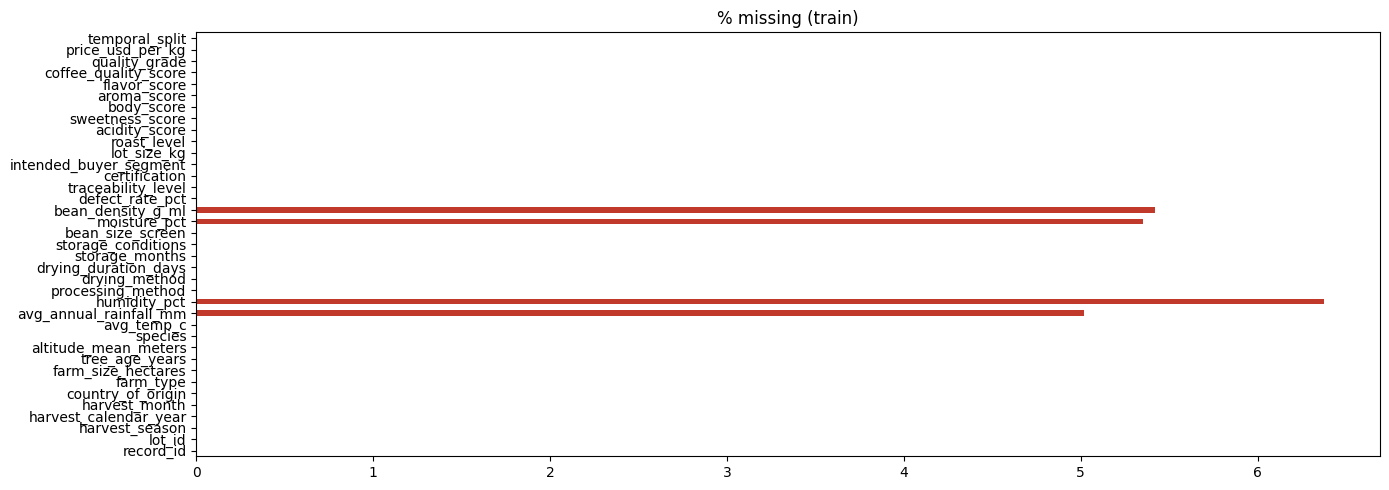

In [10]:
mv = train.isnull().sum(); mv[mv > 0]
print(pd.DataFrame({"n": mv, "pct": (mv / len(train) * 100).round(2)}))
for c in mv.index:  # is missingness random, or tied to a group?
    print(c, train.groupby("country_of_origin")[c].apply(lambda s: s.isnull().mean()).round(3).to_dict())
(mv / len(train) * 100).plot.barh(color="#c0392b", figsize=(14, 5), title="% missing (train)")
plt.tight_layout()

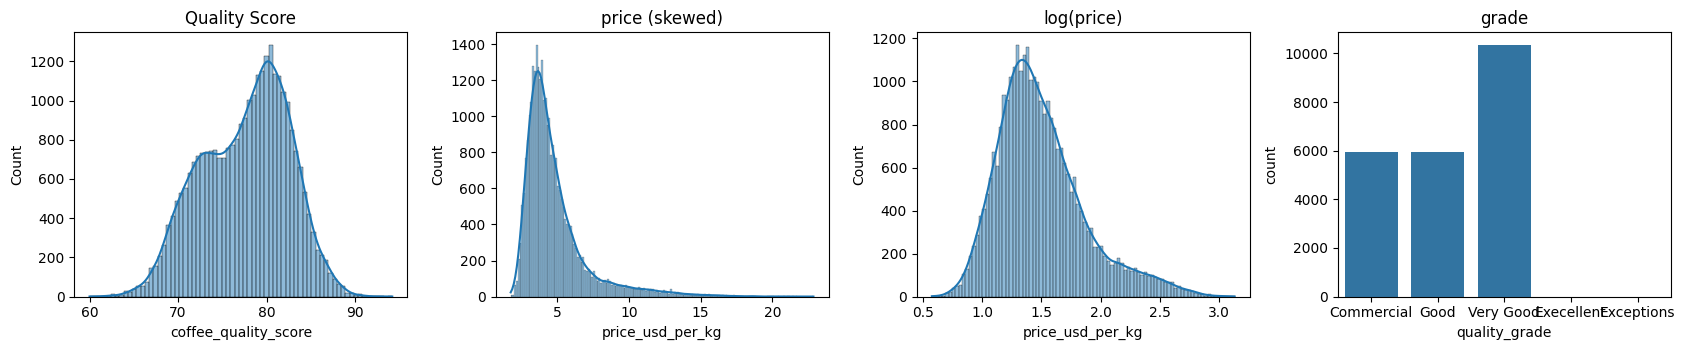

In [11]:
order = ['Commercial', "Good", "Very Good", "Execellent", "Exceptions"]

fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))

sns.histplot(train.coffee_quality_score, kde=True, ax=ax[0]); ax[0].set_title("Quality Score")

sns.histplot(train.price_usd_per_kg, kde=True, ax=ax[1]); ax[1].set_title("price (skewed)")

sns.histplot(np.log(train.price_usd_per_kg), kde=True, ax=ax[2]); ax[2].set_title("log(price)")

sns.countplot(x=train.quality_grade, order=order, ax=ax[3]); ax[3].set_title("grade")

plt.tight_layout()

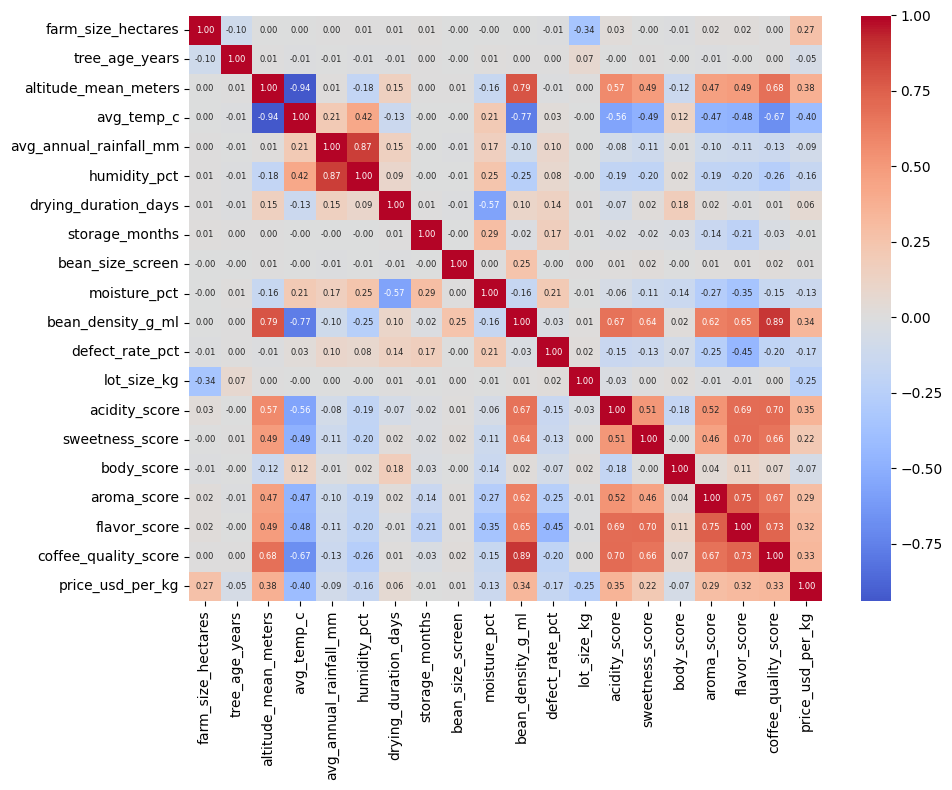

In [12]:
num = [c for c in train.select_dtypes('number').columns if c not in ("harvest_calendar_year", "harvest_month")]

plt.figure(figsize=(10,8))

sns.heatmap(train[num].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={"size": 6})

plt.tight_layout()


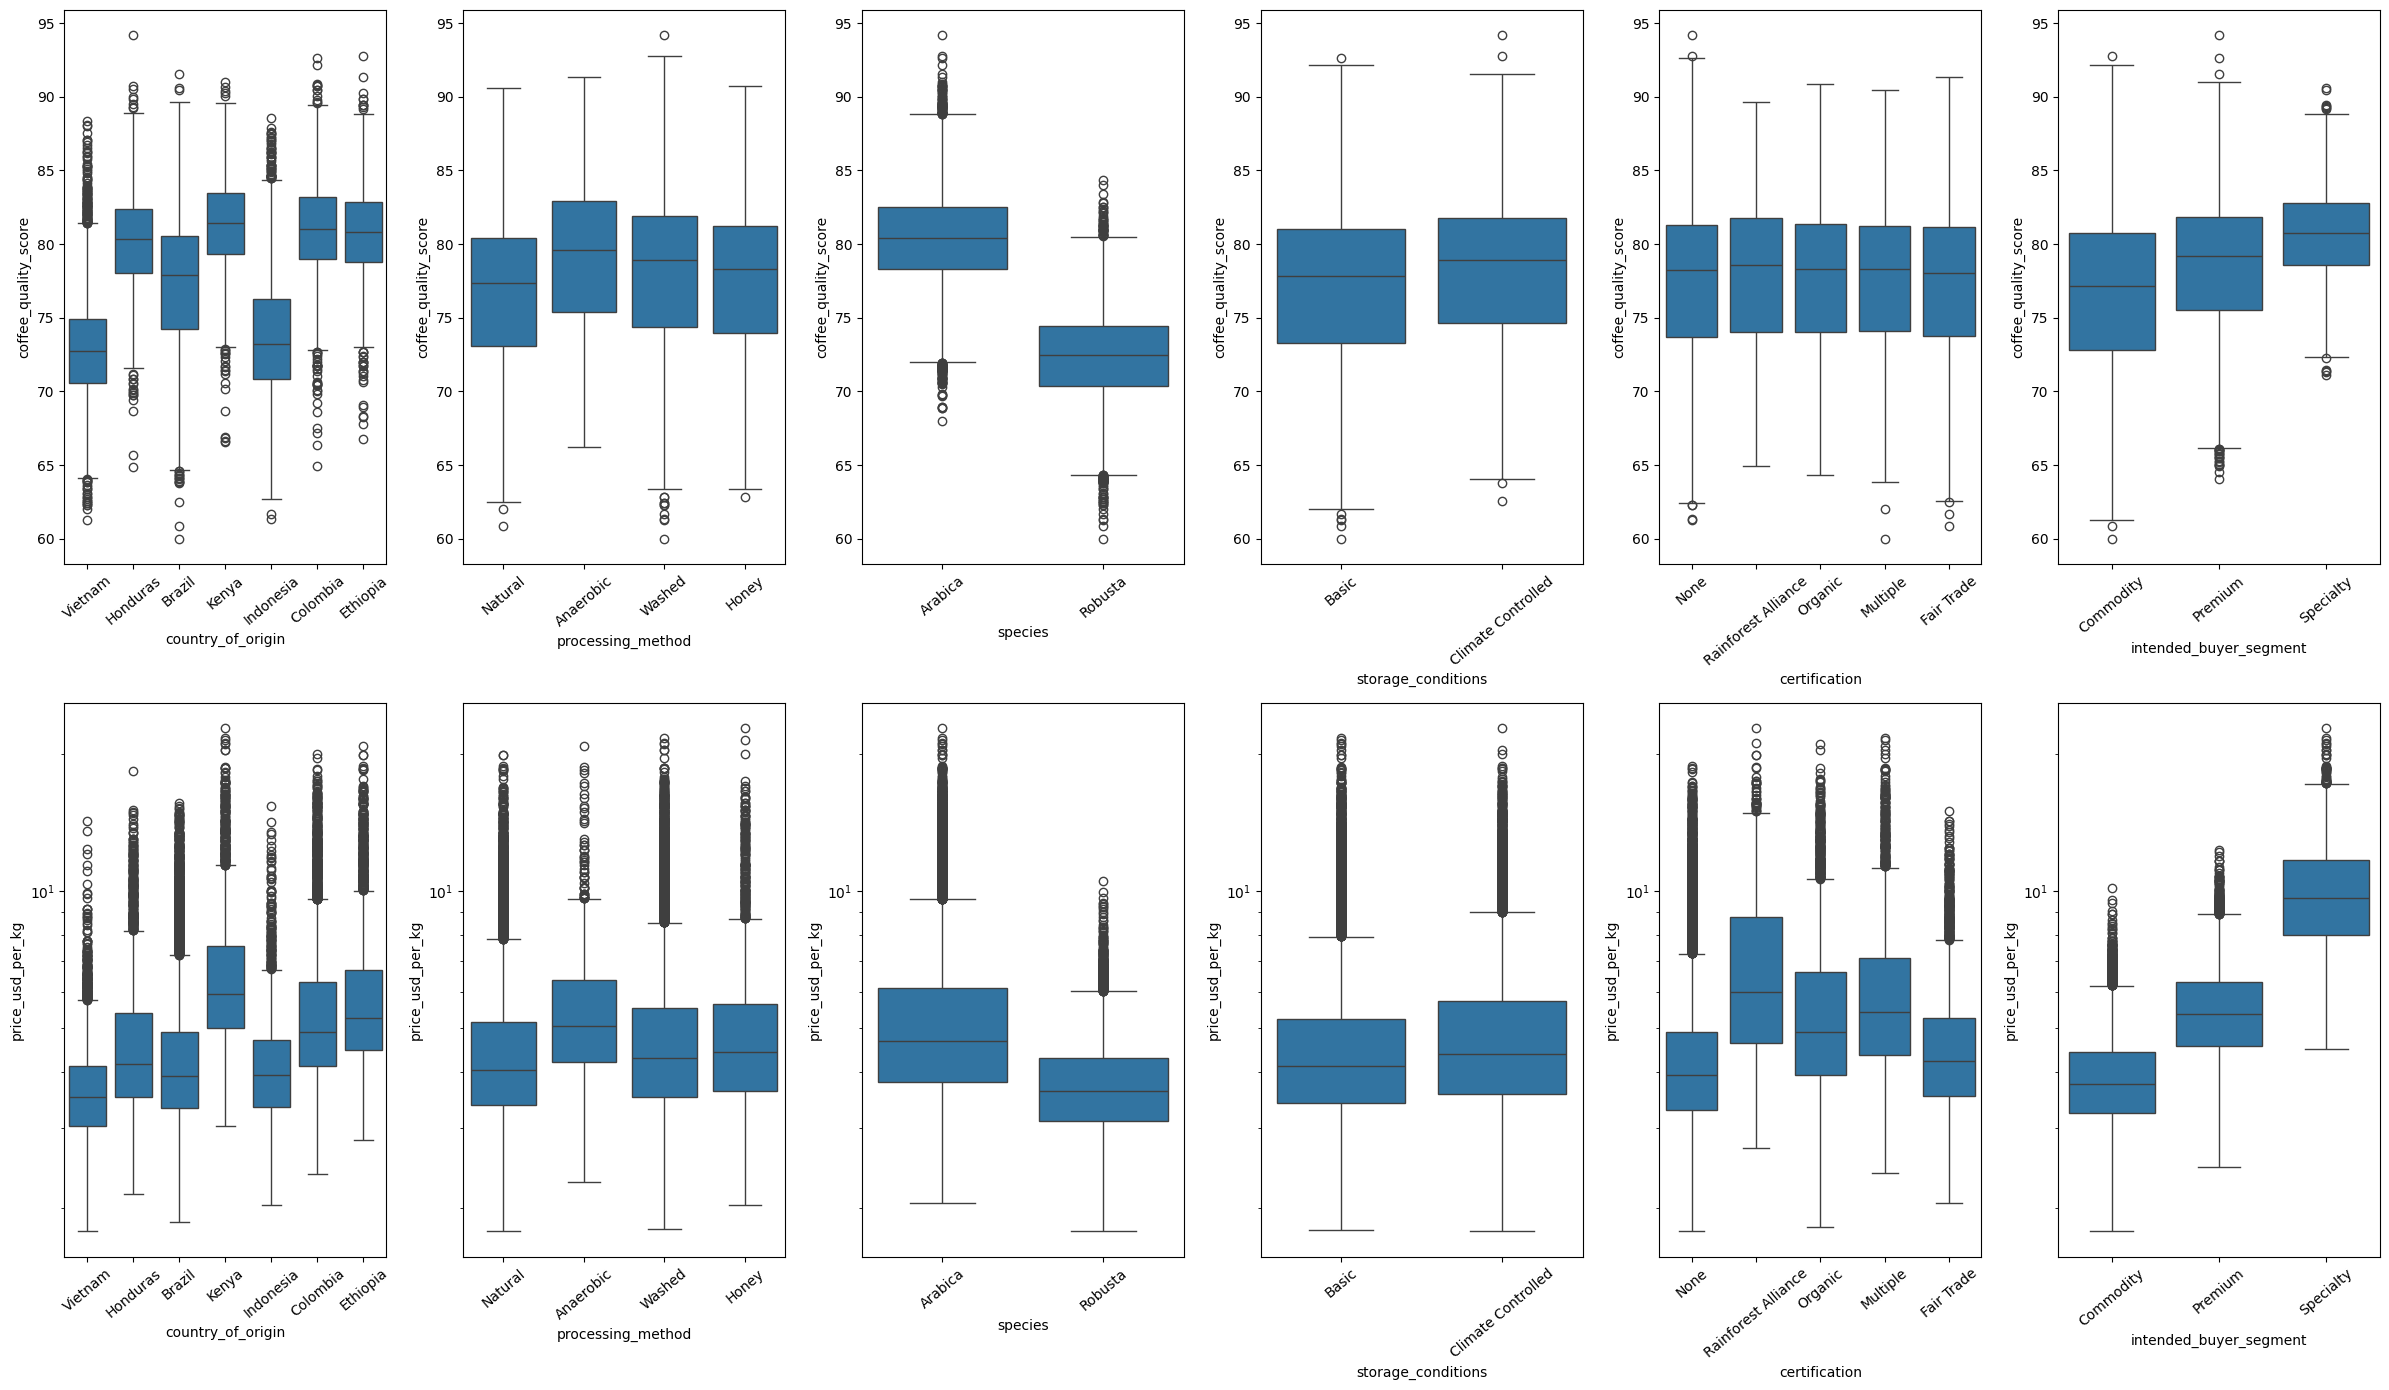

In [22]:
cat_cols = ['country_of_origin', "processing_method", "species", "storage_conditions", "certification", "intended_buyer_segment"]

fig, ax = plt.subplots(2, 6,figsize=(24, 14))

for i, k in enumerate(cat_cols):
    sns.boxplot(x=k, y="coffee_quality_score", data=train, ax=ax[0, i]); ax[0, i].tick_params(axis="x", rotation=40)   

    sns.boxplot(x=k, y="price_usd_per_kg", data=train, ax=ax[1, i]); ax[1, i].set_yscale("log")
    ax[1, i].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

In [ ]:
tc = ["harvest_season", "harvest_calendar_year"]
qf = [c for c in feature.loc[feature.usable_as_feature_for_quality, "columns"] if c not in tc]
pf = [c for c in feature.loc[feature.usable_as_feature_for_price, "columns"] if c not in tc]

def prep(d, f):
    X = d[f].copy()
    for c in ("lot_size_kg", "farm_size_hectares"):
        if c in X: X[c] = np.log1p(X[c])
    return X

def pre(X):
    cat = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    nm = [c for c in X.columns if c not in cat]
    return ColumnTransformer([("n", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), nm), ("c", OneHotEncoder(handle_unknown='ignore'), cat)])

hgb = lambda: HistGradientBoostingRegressor(random_state=42, learning_rate=0.05, max_iter=400)
bounds = train.groupby("quality_score")["coffee_quality_score"].min().loc[order].values[1:]
grade = lambda s: np.searchsorted(bounds, s, side="right")
grade_acc = lambda yt, yp: accuracy_score(grade(yt), grade(yp))
plain = lambda: Pipeline([("p", "passthrough"), ("m", hgb())])
log = lambda: Pipeline([("p", "passthrough"), ("m", TransformedTargetRegressor(hgb(), func=np.log, inverse_func=np.exp))])

jobs = [("Quality score (R2)", qf, "coffee_quality_score", plain, r2_score),
        ("Price, log-target (R2)", pf, "price_usd_per_kg", log, r2_score),
        ("Quality grade (Accuracy)", qf, "coffee_quality_score", plain, grade_acc)]

cv = KFold(5, shuffle=True, random_state=42)